In [1]:
!pip install mpi4py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mpi4py: filename=mpi4py-3.1.5-cp310-cp310-linux_x86_64.whl size=2746495 sha256=0a5b2664d283a72691d2e9fd31b2e26c386a9ad6d32fe68f01c6e0c807305d0a
  Stored in directory: /root/.cache/pip/wheels/18/2b/7f/c852523089e9182b45fca50ff56f49a51eeb6284fd25a66713
Successfully built mpi4py


In [1]:
%%writefile spectrogram.py
import matplotlib.pyplot as plt
from mpi4py import MPI
import numpy as np
import random
import time
import warnings
import os
warnings.filterwarnings('ignore')

# generate the signal
num = 2**14
nofts=1000
t=np.linspace(-20*2*np.pi, 20*2*np.pi, num)
y=np.sin(t)*np.exp(-t**2/2/20**2)
y=y+np.sin(3*t)*np.exp(-(t-5*2*np.pi)**2/2/20**2)
y=y+np.sin(5.5*t)*np.exp(-(t-10*2*np.pi)**2/2/5**2)
y=y+np.sin(4*t)*np.exp(-(t-7*2*np.pi)**2/2/10**2) #Add 4th wave packet (frequency = 4 and time_shift = 7 cycles). Demonstrate the effect on the plot of the FFT spectrum.


t_start = time.time()

comm = MPI.COMM_WORLD

rank = comm.Get_rank()
size = comm.Get_size()

nwindowsteps = 10000
rank_size = nwindowsteps // size

root = 0

window = np.linspace(-20*2*np.pi, 20*2*np.pi, nwindowsteps)

if rank == size - 1:
    rank_size += nwindowsteps % size
    start, end = rank * rank_size, nwindowsteps


else:
    start, end = rank * rank_size, (rank + 1) * rank_size


steps_number = end - start
spec = np.zeros((steps_number,num))
window_width=2.0*2*np.pi


for i, window_position in enumerate(window[start:end]):
  window_function = np.exp(-(t-window_position)**2/2/window_width**2)
  y_window = y * window_function
  sp = np.fft.fft(y_window)
  w = np.fft.fftfreq(len(y_window), d=(t[1]-t[0])/2/np.pi)
  spec[i] = abs(sp)**2


spec_all = None
if rank == 0:
    spec_all = np.empty([size, steps_number, num ], dtype='float')
comm.Gather(spec, spec_all, root=0)

if rank == root:
  t_end = time.time()
  dt = t_end - t_start
  with open('results.csv', 'a+') as f:
    f.write(f'{dt} ')





Overwriting spectrogram.py


In [2]:
for i in range(10,20,2):
  !mpirun -n $i --allow-run-as-root --oversubscribe python3 spectrogram.py

Text(0, 0.5, 'speedup')

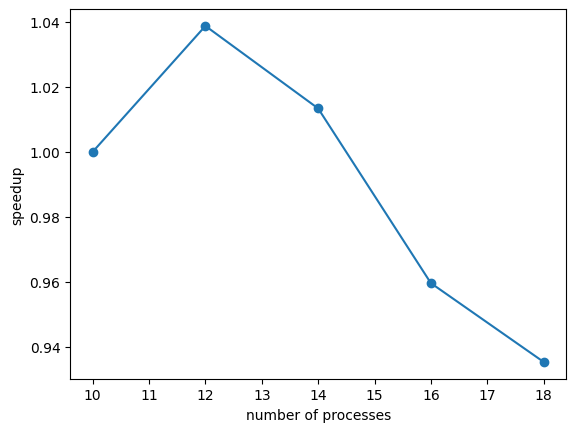

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = []
with open('results.csv', 'r') as results:
    data = results.readlines()[0].split(' ')
    data = np.array([float(i) for i in data[:-1]] )

plt.plot(range(10,20,2),data[0] / data , '-o')
plt.xlabel('number of processes')
plt.ylabel('speedup')

I used google.colab, so it is impossible to get speedup here.